# Conditional Poisson Sampling

**Why fixed-size weighted subsets?**  Many problems require selecting exactly $n$ distinct items from a larger set, with selection probabilities controlled by item-level weights: survey sampling (draw $n$ households with probabilities proportional to size), stochastic beam search (maintain exactly $n$ hypotheses weighted by model scores), or subset selection in machine learning (choose $n$ features or data points for a diverse batch).  The hard part is doing this *exactly* — getting the right distribution, computing inclusion probabilities, and fitting weights — all efficiently.

Suppose you want to draw a random subset of exactly $n$ items from a universe $\mathcal{S}$ of $N$ items, where each item has a weight ${\color{#2196F3}{w_i}} > 0$.  The probability of drawing a particular subset $S \in \tbinom{\mathcal{S}}{n}$ is proportional to the product of its weights:

$$
P(S) = \frac{\prod_{i \in S} {\color{#2196F3}{w_i}}}{{\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}}, \quad S \in \tbinom{\mathcal{S}}{n}
$$

where ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n} = \sum_{S \in \tbinom{\mathcal{S}}{n}} \prod_{i \in S} {\color{#2196F3}{w_i}}$ is the normalizing constant — a weighted generalization of the binomial coefficient (when ${\color{#2196F3}{\boldsymbol{w}}} = \mathbf{1}$, we recover ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n} = \binom{N}{n}$).

This is the **conditional Poisson distribution** (also called the *exponential* fixed-size design).  The name comes from its construction: in *Poisson sampling*, each item $i$ is included independently with probability $p_i$ — but the sample size is random.  *Conditioning* on the sample size being exactly $n$ gives the conditional Poisson distribution.  Concretely, set $p_i = {\color{#2196F3}{w_i}}/(1+{\color{#2196F3}{w_i}})$, so the weight ${\color{#2196F3}{w_i}}$ is the *odds* of the $i$-th coin flip: ${\color{#2196F3}{w_i}} = p_i / (1 - p_i)$.

Among all distributions over size-$n$ subsets with given marginal inclusion probabilities ${\color{#E91E63}{\pi_i}} = P(i \in S)$, the conditional Poisson distribution is the unique **maximum-entropy** one — it makes the fewest assumptions beyond the marginals ([Chen, Dempster & Liu, 1994](https://academic.oup.com/biomet/article-abstract/81/3/457/256956)).  This is the same sense in which the Gaussian is the max-entropy distribution with given mean and variance.

In this post, I'll describe an implementation that computes inclusion probabilities, draws exact samples, and fits weights to target probabilities — all in $O(N \log^2 N)$ time using a polynomial product tree.  The code is available as a single-file library: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling).

**As far as I can tell, this is the only publicly available library for conditional Poisson sampling in Python** (or any language outside of R's survey-sampling packages).  Existing R implementations — `UPmaxentropy` in the [sampling](https://cran.r-project.org/web/packages/sampling/) package and the [BalancedSampling](https://cran.r-project.org/web/packages/BalancedSampling/) package — use either rejection sampling or $O(Nn)$ dynamic programming.  The product-tree algorithm used here does not appear in any prior software that I'm aware of.

## Two rejection sampling constructions

There are two simple rejection sampling procedures that both produce exactly the conditional Poisson distribution.  They give useful intuition for what the distribution *is*.

**Construction 1 (Bernoulli).** For each item $i$, flip an independent coin with odds ${\color{#2196F3}{w_i}}$ (i.e., heads probability $p_i = {\color{#2196F3}{w_i}}/(1+{\color{#2196F3}{w_i}})$).  Let $S$ be the set of heads.  Reject unless $|S| = n$.

**Construction 2 (Categorical).** Draw $n$ items i.i.d. from the categorical distribution with probabilities $\propto {\color{#2196F3}{w_i}}$ (with replacement).  Reject unless all $n$ draws are distinct.

Both yield $P(S) \propto \prod_{i \in S} {\color{#2196F3}{w_i}}$ — the extra factors ($\prod_i(1+{\color{#2196F3}{w_i}})$ in construction 1, $n!$ and ${\color{#2196F3}{W}}^n$ in construction 2) are constant across all size-$n$ sets and cancel upon conditioning.

Note that in construction 1, the weight ${\color{#2196F3}{w_i}}$ is literally the *odds* of item $i$'s coin flip: ${\color{#2196F3}{w_i}} = p_i/(1-p_i)$.

In [1]:
def rejection_bernoulli(w, n, rng):
    """Construction 1: independent coins, condition on size = n."""
    p = w / (1 + w)
    attempts = 0
    while True:
        attempts += 1
        S = np.where(rng.random(len(w)) < p)[0]
        if len(S) == n:
            return S, attempts

def rejection_categorical(w, n, rng):
    """Construction 2: n draws with replacement, condition on all distinct."""
    p = w / w.sum()
    attempts = 0
    while True:
        attempts += 1
        draws = rng.choice(len(w), size=n, replace=True, p=p)
        if len(set(draws)) == n:
            return np.sort(draws), attempts

import numpy as np
rng_rej = np.random.default_rng(42)
N_rej, n_rej = 20, 5
w_rej = rng_rej.exponential(1.0, N_rej)

for name, sampler in [('Bernoulli',    rejection_bernoulli),
                       ('Categorical',  rejection_categorical)]:
    attempts = [sampler(w_rej, n_rej, rng_rej)[1] for _ in range(1000)]
    print(f'{name:12s}  mean attempts: {np.mean(attempts):5.1f}   max: {np.max(attempts)}')


Bernoulli     mean attempts:  19.7   max: 160
Categorical   mean attempts:   2.7   max: 16


The acceptance rates for the two constructions are:

| Construction | Acceptance rate |
|---|---|
| Bernoulli (condition on size $n$) | ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n} \;/\; \prod_i(1 + {\color{#2196F3}{w_i}})$ |
| Categorical (condition on all distinct) | $n! \cdot {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n} \;/\; {\color{#2196F3}{W}}^n$ |

where ${\color{#2196F3}{W}} = \sum_i {\color{#2196F3}{w_i}}$ is the total weight.  Both have ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$ in the numerator — the hard quantity.  The categorical version tends to be better when $n \ll N$ (collisions are rare — essentially the birthday problem), while the Bernoulli version can be better when the weights are spread out and $n/N$ is moderate.

**How bad can rejection get?**  With a heavy hitter (one item with probability $\alpha \to 1$), the categorical rejection sampler needs $\Omega(e^n)$ expected iterations.  Intuitively, the heavy hitter keeps getting resampled and colliding with itself.

<details class="derivation" markdown="1">
<summary>Proof (following De Vita, 2023)</summary>

Consider $N+1$ items where item 0 has probability $\alpha$ and the remaining $N$ items each have probability $\beta = (1-\alpha)/N$.  The acceptance probability for the categorical construction is

$$\Pr[\text{accept}] = \sum_{Y \in \binom{\mathcal{Y}}{n}} \prod_{y \in Y} p(y) = \alpha \binom{N}{n-1} \beta^{n-1} + \binom{N}{n} \beta^n$$

where the first term covers subsets that include the heavy hitter and the second covers those that don't.  Applying the bound $\binom{m}{k} \le (em/k)^k$ and substituting $\beta = (1-\alpha)/N$:

$$\Pr[\text{accept}] \le \frac{\alpha(1-\alpha)^{n-1} e^{n-1}}{(n-1)^{n-1}} + \frac{(1-\alpha)^n e^n}{n^n}$$

Since $n^n > (n-1)^{n-1}$ for $n \ge 2$, we can use $(n-1)^{n-1}$ as a common denominator.  Since $(1-\alpha)^n < (1-\alpha)^{n-1}$ and $e^{n-1} < e^n$, we can factor:

$$\Pr[\text{accept}] < \frac{e^n (1-\alpha)^{n-1}(1 + \alpha)}{(n-1)^{n-1}}$$

Using $1-\alpha \le e^{-\alpha}$ (a consequence of $1 + x \le e^x$), we get $(1-\alpha)^{n-1} \le e^{-\alpha(n-1)} = e^{\alpha} \cdot e^{-\alpha n} \le e^{\alpha}$, giving:

$$\Pr[\text{accept}] < \frac{e^{\alpha}(1+\alpha)\, e^n}{(n-1)^{n-1}}$$

Since $(n-1)^{n-1} = e^{(n-1)\ln(n-1)}$ grows much faster than $e^{2n}$, inverting this bound gives $1/\Pr[\text{accept}] = \Omega(e^n)$.

</details>

This is why efficient algorithms are essential.

Either way, neither construction gives you a way to compute ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$, the inclusion probabilities, or gradients for fitting.  That's the gap the product tree fills.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pylab as pl
from conditional_poisson import ConditionalPoisson

## Basic usage

The simplest entry point is `from_weights`: hand it a subset size $n$ and a weight vector ${\color{#2196F3}{\boldsymbol{w}}}$.

In [3]:
N, n = 10, 4
rng = np.random.default_rng(0)
w = rng.exponential(1.0, N)

cp = ConditionalPoisson.from_weights(n, w)
print(f'N={N}, n={n}')
print(f'weights:   {np.round(w, 3)}')
print(f'pi:        {np.round(cp.pi, 3)}')
print(f'sum(pi):   {cp.pi.sum():.6f}  (should be {n})')
print(f'log Z:     {cp.log_normalizer:.4f}')

N=10, n=4
weights:   [6.800e-01 1.020e+00 2.000e-02 2.000e-03 5.500e-01 1.630e+00 6.740e-01
 7.550e-01 2.817e+00 6.058e+00]
pi:        [0.343 0.456 0.013 0.001 0.291 0.592 0.341 0.371 0.73  0.861]
sum(pi):   4.000000  (should be 4)
log Z:     5.7602


The inclusion probabilities ${\color{#E91E63}{\pi_i}} = P(i \in S)$ always sum to $n$, and each ${\color{#E91E63}{\pi_i}} \in (0, 1)$.  Items with larger weights get higher inclusion probabilities.

## Sampling

Drawing samples works by walking a binary tree top-down, splitting a "quota" of $n$ items between the left and right subtrees at each node.  Each split is exact (not approximate), and the tree is built once and cached, so subsequent samples are cheap.

In [4]:
M = 100_000
samples = cp.sample(M, rng=rng)
print(f'sample shape: {samples.shape}')   # (M, n)
print(f'first few samples:')
print(samples[:5])

sample shape: (100000, 4)
first few samples:
[[1 4 6 9]
 [4 7 8 9]
 [1 5 7 8]
 [0 4 8 9]
 [1 5 6 8]]


Let's verify that the empirical inclusion frequencies match the exact ${\color{#E91E63}{\pi}}$ values.

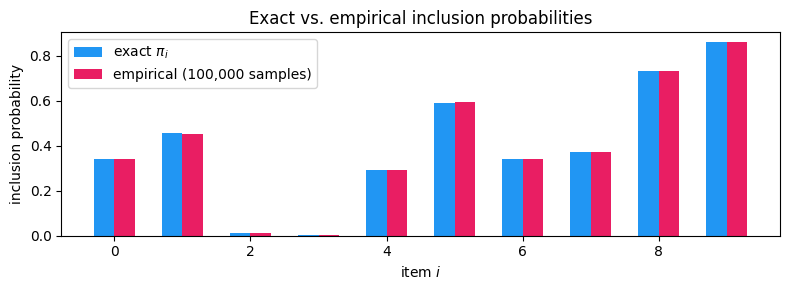

In [5]:
pi_emp = np.bincount(samples.ravel(), minlength=N) / M

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, cp.pi, width=0.3, label='exact $\pi_i$', color='#2196F3')
pl.bar(ix + 0.15, pi_emp, width=0.3, label=f'empirical ({M:,} samples)', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Exact vs. empirical inclusion probabilities')
pl.tight_layout()

## The polynomial product tree

The key idea is to encode the sum over all $\binom{N}{n}$ subsets as the coefficient of $z^n$ in a product of polynomials:

$$
(1 + {\color{#2196F3}{w_1}} z)(1 + {\color{#2196F3}{w_2}} z) \cdots (1 + {\color{#2196F3}{w_N}} z) = \sum_{k=0}^{N} {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{k}\, z^k
$$

The $n$-th coefficient is exactly ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$, the normalizing constant.  This product can be computed in $O(N \log^2 N)$ time using a divide-and-conquer strategy on a binary tree.

### Upward pass

Each leaf of a complete binary tree holds one degree-1 polynomial $(1 + {\color{#2196F3}{w_i}} z)$.  Internal nodes multiply their children's polynomials.  The root holds the full product, whose $n$-th coefficient is ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$.

For example, with $N = 8$ items, the tree has three levels of internal nodes.  At the first level, pairs of leaves are multiplied: $P_{12}(z) = (1 + {\color{#2196F3}{w_1}} z)(1 + {\color{#2196F3}{w_2}} z)$, and so on.  At the next level, $P_{1234} = P_{12} \cdot P_{34}$.  The root is $P_{12345678} = P_{1234} \cdot P_{5678}$.

```mermaid
graph BT
    L1["(1 + w₁z)"] --> N12["P₁₂ = P₁ · P₂"]
    L2["(1 + w₂z)"] --> N12
    L3["(1 + w₃z)"] --> N34["P₃₄ = P₃ · P₄"]
    L4["(1 + w₄z)"] --> N34
    L5["(1 + w₅z)"] --> N56["P₅₆ = P₅ · P₆"]
    L6["(1 + w₆z)"] --> N56
    L7["(1 + w₇z)"] --> N78["P₇₈ = P₇ · P₈"]
    L8["(1 + w₈z)"] --> N78
    N12 --> N1234["P₁₋₄ = P₁₂ · P₃₄"]
    N34 --> N1234
    N56 --> N5678["P₅₋₈ = P₅₆ · P₇₈"]
    N78 --> N5678
    N1234 --> ROOT["root: P₁₋₈"]
    N5678 --> ROOT

    style ROOT fill:#4a90d9,color:#fff
    style N1234 fill:#5fa0d9,color:#fff
    style N5678 fill:#5fa0d9,color:#fff
    style N12 fill:#7ab8e0,color:#fff
    style N34 fill:#7ab8e0,color:#fff
    style N56 fill:#7ab8e0,color:#fff
    style N78 fill:#7ab8e0,color:#fff
    style L1 fill:#b8d4e8,color:#000
    style L2 fill:#b8d4e8,color:#000
    style L3 fill:#b8d4e8,color:#000
    style L4 fill:#b8d4e8,color:#000
    style L5 fill:#b8d4e8,color:#000
    style L6 fill:#b8d4e8,color:#000
    style L7 fill:#b8d4e8,color:#000
    style L8 fill:#b8d4e8,color:#000
```

**Complexity.** At each level of the tree, the total size of the polynomials being multiplied is $O(N)$, and each multiplication is done via FFT in $O(d \log d)$ time where $d$ is the degree. The recurrence is

$$T(N) = 2\,T(N/2) + O(N \log N)$$

which solves to $T(N) = O(N \log^2 N)$ by the Master Theorem.

### Downward pass

To compute ${\color{#E91E63}{\pi_i}}$, we need the "leave-one-out" product $P^{(-i)}(z) = \prod_{j \neq i}(1 + {\color{#2196F3}{w_j}} z)$ for every item $i$.  Computing $N$ separate products would cost $O(N^2)$.  Instead, a single top-down pass computes all $N$ leave-one-out polynomials in $O(N \log^2 N)$.

The idea: at the root, the "outside" polynomial is $1$ (there's nothing outside the whole tree).  When we descend to a child, its outside is the parent's outside times the *sibling's* inside polynomial.  For example, the left child of the root gets outside $= P_{5678}$ (everything to the right), and the right child gets outside $= P_{1234}$.  Continuing down, leaf 1 gets outside $= P_{5678} \cdot P_2 \cdot P_{34}$ — which is exactly $P^{(-1)}$.  Each leaf ends up with the product of all *other* leaves' polynomials, without redundant work.

```mermaid
graph TB
    ROOT["outside = 1"] --> N1234["outside = P₅₋₈"]
    ROOT --> N5678["outside = P₁₋₄"]
    N1234 --> N12["outside = P₅₋₈ · P₃₄"]
    N1234 --> N34["outside = P₅₋₈ · P₁₂"]
    N5678 --> N56["outside = P₁₋₄ · P₇₈"]
    N5678 --> N78["outside = P₁₋₄ · P₅₆"]
    N12 --> L1["P⁽⁻¹⁾ = out₁₂ · P₂"]
    N12 --> L2["P⁽⁻²⁾ = out₁₂ · P₁"]
    N34 --> L3["P⁽⁻³⁾ = out₃₄ · P₄"]
    N34 --> L4["P⁽⁻⁴⁾ = out₃₄ · P₃"]
    N56 --> L5["P⁽⁻⁵⁾ = out₅₆ · P₆"]
    N56 --> L6["P⁽⁻⁶⁾ = out₅₆ · P₅"]
    N78 --> L7["P⁽⁻⁷⁾ = out₇₈ · P₈"]
    N78 --> L8["P⁽⁻⁸⁾ = out₇₈ · P₇"]

    style ROOT fill:#4a90d9,color:#fff
    style N1234 fill:#5fa0d9,color:#fff
    style N5678 fill:#5fa0d9,color:#fff
    style N12 fill:#7ab8e0,color:#fff
    style N34 fill:#7ab8e0,color:#fff
    style N56 fill:#7ab8e0,color:#fff
    style N78 fill:#7ab8e0,color:#fff
    style L1 fill:#d4e8b8,color:#000
    style L2 fill:#d4e8b8,color:#000
    style L3 fill:#d4e8b8,color:#000
    style L4 fill:#d4e8b8,color:#000
    style L5 fill:#d4e8b8,color:#000
    style L6 fill:#d4e8b8,color:#000
    style L7 fill:#d4e8b8,color:#000
    style L8 fill:#d4e8b8,color:#000
```

The inclusion probability is then:

$$
{\color{#E91E63}{\pi_i}} = {\color{#2196F3}{w_i}} \cdot \llbracket P^{(-i)} \rrbracket(z^{n-1}) \;/\; {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}
$$

where $\llbracket f \rrbracket(z^k)$ denotes the coefficient of $z^k$ in the formal power series $f$.

### Sampling

Sampling reuses the upward-pass tree (no downward pass needed).  Starting at the root with a quota of $k = n$ items to select, we walk top-down: at each internal node, randomly split the quota between the left and right subtrees.  The probability of assigning $j$ items to the left is proportional to $\llbracket P_L \rrbracket(z^j) \cdot \llbracket P_R \rrbracket(z^{k-j})$ — the number of ways to choose $j$ items from the left times the number of ways to choose $k-j$ from the right, weighted by the respective products.  At the leaves, quota 1 means "include this item"; quota 0 means "exclude."

```mermaid
graph TB
    ROOT["quota = n"] -->|"j₁ items"| LEFT["quota = j₁"]
    ROOT -->|"n − j₁ items"| RIGHT["quota = n − j₁"]
    LEFT -->|"j₂"| LL["quota = j₂"]
    LEFT -->|"j₁ − j₂"| LR["quota = j₁ − j₂"]
    RIGHT -->|"j₃"| RL["quota = j₃"]
    RIGHT -->|"n−j₁−j₃"| RR["quota = n−j₁−j₃"]
    LL --> L1["0 or 1"]
    LL --> L2["0 or 1"]
    LR --> L3["0 or 1"]
    LR --> L4["0 or 1"]
    RL --> L5["0 or 1"]
    RL --> L6["0 or 1"]
    RR --> L7["0 or 1"]
    RR --> L8["0 or 1"]

    style ROOT fill:#4a90d9,color:#fff
    style LEFT fill:#5fa0d9,color:#fff
    style RIGHT fill:#5fa0d9,color:#fff
    style LL fill:#7ab8e0,color:#fff
    style LR fill:#7ab8e0,color:#fff
    style RL fill:#7ab8e0,color:#fff
    style RR fill:#7ab8e0,color:#fff
    style L1 fill:#b8d4e8,color:#000
    style L2 fill:#b8d4e8,color:#000
    style L3 fill:#b8d4e8,color:#000
    style L4 fill:#b8d4e8,color:#000
    style L5 fill:#b8d4e8,color:#000
    style L6 fill:#b8d4e8,color:#000
    style L7 fill:#b8d4e8,color:#000
    style L8 fill:#b8d4e8,color:#000
```

In pseudocode:

```python
def sample(node, quota):
    if node.is_leaf:
        return [node.item] if quota == 1 else []
    # P_L[j] * P_R[quota-j] for j = 0, ..., quota
    probs = [node.left.poly[j] * node.right.poly[quota - j]
             for j in range(quota + 1)]
    j = categorical(probs)              # how many items from the left subtree
    return sample(node.left, j) + sample(node.right, quota - j)

S = sample(root, n)                     # exactly n items
```

The tree is built once ($O(N \log^2 N)$) and reused for each sample ($O(n \log N)$ per sample) — at each of the $O(\log N)$ levels, only nodes whose quota is nonzero are visited, and there are at most $n$ such nodes.  No $\binom{N}{n}$-sized table is ever constructed.

This is essentially the same divide-and-conquer structure I described in the [heaps for incremental computation](https://timvieira.github.io/blog/heaps-for-incremental-computation/) post, but over polynomials instead of scalars.

## Brute-force verification

For small instances, we can enumerate all $\binom{N}{n}$ subsets and verify that the efficient algorithm gets the right answer.

In [ ]:
from itertools import combinations

N_small, n_small = 7, 3
w_small = rng.exponential(1.0, N_small)
cp_small = ConditionalPoisson.from_weights(n_small, w_small)

# Brute force: enumerate all subsets
all_S = list(combinations(range(N_small), n_small))
log_unnorm = np.array([np.log(np.prod(w_small[list(s)])) for s in all_S])
log_Z_bf = np.log(np.exp(log_unnorm).sum())   # log Z from brute force
log_probs_bf = log_unnorm - log_Z_bf           # normalise

# Inclusion probabilities from brute force
probs_bf = np.exp(log_probs_bf)
pi_bf = np.zeros(N_small)
for k, s in enumerate(all_S):
    for i in s:
        pi_bf[i] += probs_bf[k]

print(f'max |pi_tree - pi_brute_force| = {np.max(np.abs(cp_small.pi - pi_bf)):.2e}')
print(f'sum P(S) via brute force       = {probs_bf.sum():.10f}')
print(f'log Z: tree={cp_small.log_normalizer:.6f}, brute force={log_Z_bf:.6f}')

## Fitting weights to target probabilities

A common use case: you know the inclusion probabilities you *want* (e.g., from a survey design or an optimal allocation), and you need to find weights that produce them.

This is a convex optimization problem.  Since $\log P(S) = \sum_{i \in S} \theta_i - \log {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$, we maximise the expected log-probability under the target marginals:

$$
L(\theta) = {\color{#E91E63}{\pi^{*\top}}} \theta - \log {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}
$$

This is convex because $\log {\color{#FF9800}{Z}}$ is a log-partition function (the distribution is an exponential family with sufficient statistics $\mathbf{1}[i \in S]$).  The gradient is ${\color{#E91E63}{\pi^*}} - {\color{#E91E63}{\pi}}(\theta)$ and the Hessian is $-\text{Cov}[\mathbf{1}_S]$, the negative covariance matrix of the inclusion indicators.  We use Newton-CG — the Hessian-vector product $\text{Cov}[\mathbf{1}_S]\, v$ is computed efficiently via the D-tree (a second tree that piggybacks on the P-tree).

In [7]:
# Target: the inclusion probabilities from our earlier example
pi_star = cp.pi.copy()

# Fit from scratch
cp_fit = ConditionalPoisson.fit(pi_star, n, verbose=True)

  iter   0:  max|pi*-pi| = 3.332e-02
  iter   1:  max|pi*-pi| = 2.606e-03
  iter   2:  max|pi*-pi| = 2.036e-05
  iter   3:  max|pi*-pi| = 1.994e-09
  iter   4:  max|pi*-pi| = 7.661e-15


max |pi_fit - pi_target| = 8.27e-15


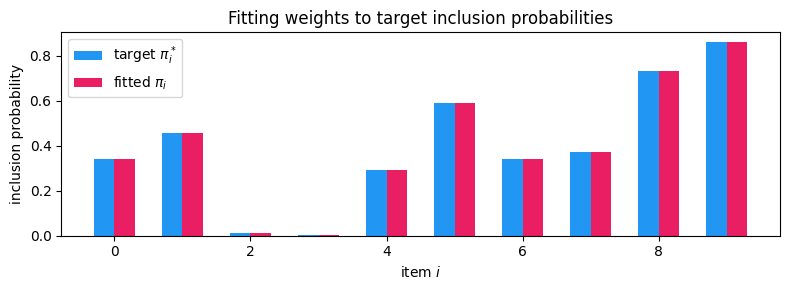

In [8]:
print(f'max |pi_fit - pi_target| = {np.max(np.abs(cp_fit.pi - pi_star)):.2e}')

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, pi_star, width=0.3, label='target $\pi^*_i$', color='#2196F3')
pl.bar(ix + 0.15, cp_fit.pi, width=0.3, label='fitted $\pi_i$', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Fitting weights to target inclusion probabilities')
pl.tight_layout()

## Numerical stability

The implementation handles extreme weight ranges without overflow.  Every polynomial in the tree is stored in a scaled representation `(coeffs, log_scale)` with $\max|c_k| = 1$, so FFT convolutions always operate on $O(1)$-magnitude numbers.  Weights are also geometrically normalised before each tree build.

Let's verify with some stress tests.

In [9]:
cases = [
    ('large positive theta',  ConditionalPoisson(4, rng.uniform(30, 50, 10))),
    ('large negative theta',  ConditionalPoisson(4, rng.uniform(-50, -30, 10))),
    ('wide range theta',      ConditionalPoisson(4, np.linspace(-30, 30, 10))),
    ('N=100, n=50, uniform',  ConditionalPoisson(50, np.full(100, 2.0))),
    ('N=200, n=100, uniform', ConditionalPoisson(100, np.full(200, 10.0))),
    ('N=500, n=250, uniform', ConditionalPoisson(250, np.full(500, 5.0))),
]

print(f'{"case":30s}  {"sum(pi)":>10s}  {"log Z":>12s}  {"ok":>4s}')
print('-' * 62)
for name, cpt in cases:
    pi_t = cpt.pi
    ok = (np.isfinite(pi_t).all() and np.isfinite(cpt.log_normalizer)
          and abs(pi_t.sum() - cpt.n) < 1e-4)
    print(f'{name:30s}  {pi_t.sum():10.4f}  {cpt.log_normalizer:12.2f}  {"✓" if ok else "✗":>4s}')

case                               sum(pi)         log Z    ok
--------------------------------------------------------------
large positive theta                4.0000        185.40     ✓
large negative theta                4.0000       -138.80     ✓
wide range theta                    4.0000         80.00     ✓
N=100, n=50, uniform               50.0000        166.78     ✓
N=200, n=100, uniform             100.0000       1135.75     ✓
N=500, n=250, uniform             250.0000       1593.24     ✓


## Timing

The tree-based approach scales to moderately large $N$ comfortably.

In [10]:
import time

print(f'{"N":>6s}  {"n":>6s}  {"pi (ms)":>10s}  {"hvp (ms)":>10s}  {"10k samples (ms)":>18s}')
print('-' * 56)
for N_t, n_t in [(50, 20), (100, 40), (200, 80), (500, 200)]:
    w_t = rng.exponential(1.0, N_t)
    v_t = rng.standard_normal(N_t)
    cp_t = ConditionalPoisson.from_weights(n_t, w_t)

    reps = max(1, int(800 / (N_t * n_t**0.5)))

    t0 = time.perf_counter()
    for _ in range(reps): cp_t._cache.clear(); cp_t.pi
    pi_ms = (time.perf_counter() - t0) / reps * 1000

    t0 = time.perf_counter()
    for _ in range(reps): cp_t.hvp(v_t)
    hvp_ms = (time.perf_counter() - t0) / reps * 1000

    t0 = time.perf_counter()
    cp_t.sample(10_000, rng=rng)
    samp_ms = (time.perf_counter() - t0) * 1000

    print(f'{N_t:>6d}  {n_t:>6d}  {pi_ms:>10.1f}  {hvp_ms:>10.1f}  {samp_ms:>18.0f}')

     N       n     pi (ms)    hvp (ms)    10k samples (ms)
--------------------------------------------------------
    50      20         5.9        20.0                  30
   100      40        15.7        35.1                  71
   200      80        24.0        77.3                 146
   500     200        51.0       176.6                 381


## Application: Horvitz-Thompson estimation

A key application of CPS is unbiased estimation via the Horvitz-Thompson estimator.  Given a distribution $p$ over a universe $\mathcal{Y}$, we want to estimate $\mu = \sum_y p(y) f(y)$ without evaluating $f$ on every element.

Drawing $n$ distinct elements $Y \sim P_n$ and applying the **Horvitz-Thompson estimator**:

$$
\hat{\mu}_{\text{HT}}(Y) = \sum_{y \in Y} \frac{p(y)}{{\color{#E91E63}{\pi(y)}}} f(y), \quad Y \sim P_n
$$

gives an unbiased estimate: $\mathbb{E}[\hat{\mu}_{\text{HT}}] = \mu$, provided ${\color{#E91E63}{\pi(y)}} > 0$ whenever $p(y) > 0$.

The advantage over Monte Carlo (i.i.d. sampling): MC wastes evaluations resampling high-probability elements, while SWOR guarantees $n$ *distinct* evaluations.  CPS makes this practical because we can efficiently compute both the samples and the inclusion probabilities ${\color{#E91E63}{\pi(y)}}$ that the estimator needs.

For more on SWOR-based estimation (including the near-optimal priority sampling scheme), see my earlier post on [estimating means in a finite universe](https://timvieira.github.io/blog/post/2017/07/03/estimating-means-in-a-finite-universe/).

## Identities for ${\color{#FF9800}{Z}}$ and its relatives

The normalizing constant ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$ is the $n$-th elementary symmetric polynomial $e_n({\color{#2196F3}{\boldsymbol{w}}})$.  Here are some useful identities.

**Generating function.** Everything flows from:

$$\prod_{i=1}^{N}(1 + {\color{#2196F3}{w_i}} z) = \sum_{k=0}^{N} {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{k}\, z^k$$

**Differential identities.** Since this is an exponential family with natural parameter $\theta_i = \log {\color{#2196F3}{w_i}}$:

$${\color{#E91E63}{\pi_i}} = \frac{\partial \log {\color{#FF9800}{Z}}}{\partial \theta_i}, \qquad \text{Cov}[Z_i, Z_j] = \frac{\partial^2 \log {\color{#FF9800}{Z}}}{\partial \theta_i \partial \theta_j}$$

Equivalently, ${\color{#E91E63}{\pi_i}} = {\color{#2196F3}{w_i}} \frac{\partial {\color{#FF9800}{Z}}}{\partial {\color{#2196F3}{w_i}}} / {\color{#FF9800}{Z}}$.

**Leave-one-out.** The inclusion probability has a simple form in terms of the leave-one-out normalizer:

$${\color{#E91E63}{\pi_i}} = \frac{{\color{#2196F3}{w_i}} \cdot {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}^{(-i)}}{n-1}}{{\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}}$$

where ${\color{#2196F3}{\boldsymbol{w}}}^{(-i)}$ is the weight vector with item $i$ removed.  This generalizes to **higher-order inclusion probabilities**: $\pi(X) = P(X \subseteq S) = \prod_{i \in X} {\color{#2196F3}{w_i}} \cdot {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}^{(-X)}}{n-|X|} / {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$.

**Weighted Pascal recurrence.** The $O(Nn)$ dynamic programming algorithm for ${\color{#FF9800}{Z}}$:

$${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{w_1}}, \ldots, {\color{#2196F3}{w_m}}}{k} = {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{w_1}}, \ldots, {\color{#2196F3}{w_{m-1}}}}{k} + {\color{#2196F3}{w_m}} \cdot {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{w_1}}, \ldots, {\color{#2196F3}{w_{m-1}}}}{k-1}$$

This is a weighted generalization of Pascal's identity $\binom{m}{k} = \binom{m-1}{k} + \binom{m-1}{k-1}$.  Include item $m$ (second term) or exclude it (first term).

**Vandermonde's identity (weighted).** For disjoint groups $A, B$:

$${\color{#FF9800}{Z}}\tbinom{({\color{#2196F3}{\boldsymbol{a}}}, {\color{#2196F3}{\boldsymbol{b}}})}{k} = \sum_{j=0}^{k} {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{a}}}}{j} \cdot {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{b}}}}{k-j}$$

This is why polynomial multiplication computes ${\color{#FF9800}{Z}}$: the coefficients of $P_A(z) \cdot P_B(z)$ are exactly the convolution of the two groups' elementary symmetric polynomials.  It is the identity that makes the product tree correct.

**Newton's identities.** The elementary symmetric polynomials can be computed from **power sums** $g_k = \sum_i {\color{#2196F3}{w_i}}^k$:

$${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{k} = \sum_{i=1}^{k} \frac{(-1)^{i-1}}{k}\, {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{k-i} \cdot g_i$$

This is an $O(Nn)$ algorithm that only needs the power sums, not the individual weights — useful when the universe is implicitly defined (e.g., paths in a weighted finite-state automaton, where $g_k$ can be computed via matrix methods).

## Summary

The conditional Poisson distribution is the natural maximum-entropy distribution over fixed-size subsets.  The polynomial product tree gives us an efficient way to compute everything we need:

 * **Upward pass**: builds the product polynomial $\prod_i (1 + {\color{#2196F3}{w_i}} z)$ in a binary tree.  The root's $n$-th coefficient is the normalizing constant ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$.

 * **Downward pass**: propagates leave-one-out polynomials to every leaf, giving inclusion probabilities ${\color{#E91E63}{\pi_i}}$ in a single $O(N \log^2 N)$ sweep.

 * **Sampling**: walks the tree top-down, splitting a quota at each node.  Each sample costs $O(n \log N)$.  The tree is built once and reused.

 * **Hessian-vector products**: a second "D-tree" piggybacks on the P-tree, enabling Newton-CG fitting to target inclusion probabilities.

The tree build cost follows the divide-and-conquer recurrence $T(N) = 2\,T(N/2) + O(N \log N)$, giving $T(N) = O(N \log^2 N)$.  All polynomials use a scaled representation that prevents floating-point overflow even for extreme weights.

Code: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling)

**References:**

- [Hájek (1964)](https://doi.org/10.1214/aoms/1177700375). "Asymptotic Theory of Rejective Sampling with Varying Probabilities from a Finite Population." *The Annals of Mathematical Statistics*, 35(4), 1491–1523.

- [Chen, Dempster & Liu (1994)](https://academic.oup.com/biomet/article-abstract/81/3/457/256956). "Weighted Finite Population Sampling to Maximize Entropy." *Biometrika*, 81(3), 457–469.

- [Tillé (2006)](https://link.springer.com/book/10.1007/978-0-387-34240-0). *Sampling Algorithms*. Springer.

- [Meister, Amini, Vieira & Cotterell (2021)](https://aclanthology.org/2021.emnlp-main.52/). "Conditional Poisson Stochastic Beams." *Proceedings of EMNLP 2021*.